# SWOT along-track spectra: Unsmoothed vs. 1-D-filtered prediction vs. Expert (observed)

Three curves are compared, for a given swath:

1. **Unsmoothed 1-D spectrum** — the observed 250-m posting along-track
   spectrum, `S_1D^250m(kx)`.
2. **1-D-filtered prediction** — `S_1D^250m(kx)` multiplied by the
   power transfer function of the along-track (1-D) Hamming filter,
   `|H(kx)|^2`, then truncated at the 2-km Nyquist wavenumber.
3. **1-D-aliased prediction** — `S_1D^2km(kx)` multiplied by the
   power transfer function of the along-track (1-D) Hamming filter,
   `|H(kx)|^2`, and decimated to 2km.
   
4. **Expert 1-D spectrum (observed)** — the actual observed 2-km
   posting along-track spectrum, computed directly from the Expert
   granule.

**Important caveat.** SWOT's real on-ground processing filters
**two-dimensionally** (along-track *and* cross-track) before subsampling to 2 km. Curve (2) here only applies the **along-track** component of that filter to the already along-track-only Unsmoothed spectrum — it does not know about the cross-track filter or about aliasing from subsampling.

In [1]:
import sys
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from swot_analysis import compute_pass_spectra, split_left_right_swaths, load_swot_l2_expert 

plt.rcParams["figure.dpi"] = 110

## 1. Inputs


In [2]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
EXPERT_FILE     = 'SWOT_L2_LR_SSH_Expert_0524/SWOT_L2_LR_SSH_Expert_016_074_20240531T192537_20240531T201622_PGD0_01.nc'
UNSMOOTHED_FILE = 'SWOT_L2_LR_SSH_Unsmoothed_016_074_20240531T192538_20240531T201625_PGD0_01.nc'

SSH_VAR = 'ssha_karin_2'
HRET    = False

In [3]:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=HRET)

ds_unsmooth_left = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='left')
ds_unsmooth_right = xr.open_dataset(DATA_DIR+UNSMOOTHED_FILE, group='right')

ds_unsmooth_left  = ds_unsmooth_left.assign_coords({'num_pixels':ds_unsmooth_left.num_pixels})
ds_unsmooth_right = ds_unsmooth_right.assign_coords({'num_pixels':ds_unsmooth_right.num_pixels+ds_unsmooth_right.num_pixels.values[-1]+1})
ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')
ssha = (ds_unsmooth[SSH_VAR] + ds_unsmooth['height_cor_xover'])
for qual_name in (f'{SSH_VAR}_qual', 'ssha_karin_2_qual', 'ssh_karin_2_qual'):
    if qual_name in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[qual_name] == 0)
        break
for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
    if scf in ds_unsmooth.variables:
        ssha = ssha.where(ds_unsmooth[scf] == 0)
        break
if 'surface_type' in ds_unsmooth.variables:
    ssha = ssha.where(ds_unsmooth['surface_type'] == 0)
    #ssha = np.ma.masked_where(np.abs(ssha)<2,ssha).data
mask = np.where((ssha<2.0)&(ssha>-2.0))
lat = ds_unsmooth['latitude'].values
lon = ds_unsmooth['longitude'].values
xtrack = np.array(ds_unsmooth['cross_track_distance'], dtype='float64')
xtrack = ds_unsmooth['cross_track_distance'].values
ssha = ssha.where(np.abs(ssha)<2.0)

data_unsmoothed = {'ssha': ssha.values, 'latitude': lat,'longitude': lon,'cross_track_distance': xtrack}

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_19214/1026903993.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_unsmooth       = xr.concat([ds_unsmooth_left,ds_unsmooth_right],dim='num_pixels')
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_19214/1026903993.py:8: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) 

In [4]:
# --- Unsmoothed (250-m) product ------------------------------
# ssha_us, lat_us, lon_us : (num_lines, num_pixels)
# xtrack_us               : (num_pixels,) or (num_lines, num_pixels)
ssha_us        = data_unsmoothed['ssha']
lat_us, lon_us = data_unsmoothed['latitude'], data_unsmoothed['longitude']
xtrack_us      = data_unsmoothed['cross_track_distance'] 

# --- Expert (2-km) product ------------------------------------
# ssha_ex, lat_ex, lon_ex : (num_lines, num_pixels)
# xtrack_ex               : (num_pixels,) or (num_lines, num_pixels)
ssha_ex        = data_expert['ssha']
lat_ex, lon_ex = data_expert['latitude'], data_expert['longitude']
xtrack_ex      = data_expert['cross_track_distance'] 

for name in ("ssha_us", "lat_us", "lon_us", "xtrack_us",
             "ssha_ex", "lat_ex", "lon_ex", "xtrack_ex"):
    if name not in globals():
        raise NameError(
            f"Expected variable '{name}' not found. Load the Unsmoothed "
            f"and Expert granules before running this notebook (see the "
            f"intro cell for the expected variable names)."
        )

print("Unsmoothed ssha shape:", ssha_us.shape)
print("Expert     ssha shape:", ssha_ex.shape)

Unsmoothed ssha shape: (81927, 480)
Expert     ssha shape: (9866, 69)


## 2. Analysis parameters

`segment_length_km` controls the along-track FFT length / low-`kx`
resolution trade-off. `SWATH` picks which swath ("left" or "right") to analyze.

In [5]:
SEGMENT_LENGTH_KM = 1000.0     # along-track segment length (km)
OVERLAP = 0.5                # fractional segment overlap
SWATH = "left"              # "left" or "right"
DETREND = 'constant'
# 2-km posting Nyquist wavenumber (Expert product along-track sampling)
DX_EXPERT_KM = 2.0
K_NY_2KM = 1.0 / (2.0 * DX_EXPERT_KM)   # 0.25 cpkm

# convert SSHA (assumed meters) to cm^2/cpkm units for the plot
SSHA_UNITS_TO_CM = 100.0
PSD_UNIT_SCALE = SSHA_UNITS_TO_CM ** 2

## 3. Unsmoothed 1-D along-track spectrum (observed 250-m posting)

Directly from `compute_pass_spectra()` — segments are Welch-averaged
along-track, and within each segment the per-column periodograms are
averaged over cross-track pixels. This is curve (1).

In [6]:
spectra_us_1d = compute_pass_spectra(
    ssha=ssha_us, latitude=lat_us, longitude=lon_us,
    cross_track_distance=xtrack_us,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    detrend=DETREND
)
result_us_1d = spectra_us_1d[SWATH]

kx_us = result_us_1d.wavenumber
psd_us = result_us_1d.mean_psd * PSD_UNIT_SCALE

print(f"Unsmoothed 1-D: {result_us_1d.n_segments_used}/{result_us_1d.n_segments_total} segments used")

Unsmoothed 1-D: 19/40 segments used


## 4. Along-track (1-D) Hamming filter transfer function

The real SWOT Unsmoothed -> Expert processing convolves with a 17-point
**2-D** Hamming kernel; this section reproduces only its **along-track**
1-D marginal, `H(kx)`, so it can be applied directly to the 1-D
Unsmoothed spectrum above without needing any cross-track/2-D data.
`dx_km` is the native Unsmoothed along-track sample spacing, recovered
from the `compute_pass_spectra` wavenumber axis.

In [7]:
def hamming_1d_taps(n=17):
    """17-point Hamming kernel, symmetric about 0, unit DC gain."""
    m = np.arange(n) - (n - 1) / 2   # -8 ... 8
    w = 0.54 - 0.46 * np.cos(2 * np.pi * (m + (n - 1) / 2) / (n - 1))
    return m, w / w.sum()


def hamming_transfer_1d(k, dx_km, n=17):
    """W(k): 1-D discrete-time Fourier transform of the Hamming kernel,
    at wavenumber(s) k (cpkm), for a kernel on a grid with spacing
    dx_km (km)."""
    m, w = hamming_1d_taps(n)
    k = np.asarray(k, dtype=float)
    phase = 2 * np.pi * np.multiply.outer(k, m * dx_km)
    return (w * np.cos(phase)).sum(axis=-1)


# recover the native Unsmoothed along-track spacing from the kx grid:
# for a one-sided (periodogram-style) axis, spacing ~ 1 / (2 * kx_Nyquist)
dx_native_km = 1.0 / (2.0 * kx_us.max())
print(f"Recovered native along-track spacing: {dx_native_km:.4f} km")

Wx2 = hamming_transfer_1d(kx_us, dx_native_km) ** 2

# sanity check: half-power point should sit near lambda_c ~ 6.28 km (Chelton 2024)
k_half = kx_us[np.argmin(np.abs(Wx2 - 0.5))]
print(f"Along-track half-power wavenumber: {k_half:.4f} cpkm "
      f"(wavelength {1/k_half:.2f} km; expected ~6.28 km)")

Recovered native along-track spacing: 0.2385 km
Along-track half-power wavenumber: 0.1670 cpkm (wavelength 5.99 km; expected ~6.28 km)


## 5. 1-D-filtered prediction

$$S_{1D}^{\,\rm 1D\text{-}filtered}(k_x) = |H(k_x)|^2\,S_{1D}^{250m}(k_x),\qquad |k_x|\le k_{Ny}^{2km}$$

Remember: this only removes the
along-track component of the filter's roll-off.

In [44]:
#S1D_filtered = Wx2 * psd_us / PSD_UNIT_SCALE   # apply in native units, rescale below

S1D_filtered_seg = np.zeros((len(result_us_1d.segments),kx_us.size))
for i in range(len(result_us_1d.segments)):
    _ = result_us_1d.segments[i]
    S1D_filtered_seg[i,:] = Wx2 * _.psd
    
S1D_filtered = np.nanmean(S1D_filtered_seg,axis=0) / PSD_UNIT_SCALE

in_2km_band = kx_us <= K_NY_2KM
kx_filtered = kx_us[in_2km_band]
psd_filtered = (S1D_filtered * PSD_UNIT_SCALE)[in_2km_band]

print(f"1-D-filtered prediction covers kx in [{kx_filtered.min():.4f}, "
      f"{kx_filtered.max():.4f}] cpkm (Expert Nyquist = {K_NY_2KM} cpkm)")

1-D-filtered prediction covers kx in [0.0000, 0.2500] cpkm (Expert Nyquist = 0.25 cpkm)


In [9]:
# --- Aliased 2-km prediction (along-track filtering + along-track subsampling) ---
# Real SWOT processing subsamples every M = dx_expert / dx_native native
# samples after filtering. That folds spectral energy from above the new
# (2-km) Nyquist wavenumber back into the resolved band -- this is the
# actual aliasing mechanism, not just a truncation. Using only the 1-D
# along-track filtered spectrum from Section 5, we predict this aliasing
# by summing periodic images of the (two-sided) filtered spectrum, spaced
# 2*K_NY_2KM apart, exactly as real subsampling does. This still only
# captures along-track filtering/subsampling; the cross-track filter's
# contribution is not represented (see the caveat in the intro cell).

M_SUBSAMPLE = int(round(DX_EXPERT_KM / dx_native_km))
print(f"Along-track subsampling factor: {M_SUBSAMPLE}")

# mirror the one-sided filtered spectrum into a two-sided spectrum (S is
# even in kx for a real field); one-sided psd already folds +/-k together,
# so split that power back across +k and -k before summing periodic images
kx_two_sided = np.concatenate([-kx_us[::-1][:-1], kx_us])
S_two_sided = np.concatenate([S1D_filtered[::-1][:-1], S1D_filtered])
S_two_sided[kx_two_sided != 0] /= 2.0


def aliased_two_sided(k_query, k_grid, S_grid, k_ny_new, M):
    # Sum M periodic images of the two-sided spectrum, spaced by
    # 2*k_ny_new, to predict the aliased spectrum after downsampling
    # by integer factor M.
    total = np.zeros_like(k_query, dtype=float)
    half = M // 2
    for p in range(-half, M - half):
        shifted = k_query + p * 2.0 * k_ny_new
        total += np.interp(shifted, k_grid, S_grid, left=0.0, right=0.0)
    return total


kx_alias = kx_us[kx_us <= K_NY_2KM]
S_alias_two_sided = aliased_two_sided(kx_alias, kx_two_sided, S_two_sided, K_NY_2KM, M_SUBSAMPLE)

# back to one-sided convention (double for k>0, DC stays as is)
S_alias_one_sided = np.where(kx_alias > 0, 2.0 * S_alias_two_sided, S_alias_two_sided)
psd_aliased_pred = S_alias_one_sided * PSD_UNIT_SCALE

print(f"Aliased prediction covers kx in [{kx_alias.min():.4f}, "
      f"{kx_alias.max():.4f}] cpkm ({len(kx_alias)} points)")

Along-track subsampling factor: 8
Aliased prediction covers kx in [0.0000, 0.2500] cpkm (251 points)


## 6. Expert product 1-D spectrum (observed)

Same `compute_pass_spectra()` estimator, now run on the Expert (2-km
posting) granule. This is curve (3), the actual observed spectrum.

In [10]:
spectra_ex_1d = compute_pass_spectra(
    ssha=ssha_ex, latitude=lat_ex, longitude=lon_ex,
    cross_track_distance=xtrack_ex,
    segment_length_km=SEGMENT_LENGTH_KM,
    along_track_spacing_km=DX_EXPERT_KM,
    overlap=OVERLAP,
    detrend=DETREND
)
result_ex_1d = spectra_ex_1d[SWATH]

kx_ex = result_ex_1d.wavenumber
psd_ex = result_ex_1d.mean_psd * PSD_UNIT_SCALE

print(f"Expert 1-D: {result_ex_1d.n_segments_used}/{result_ex_1d.n_segments_total} segments used")

Expert 1-D: 18/39 segments used


## 7. Comparison plot

Unsmoothed spectrum (dotted), the along-track-only filtered prediction
(dash-dot), and the observed Expert spectrum (solid). Any gap between
the dash-dot and solid lines reflects **both** the missing cross-track
filter component **and** aliasing — this notebook can't separate the
two (see the caveat above); use `swot_spectra_comparison.ipynb` if you
need that separation.

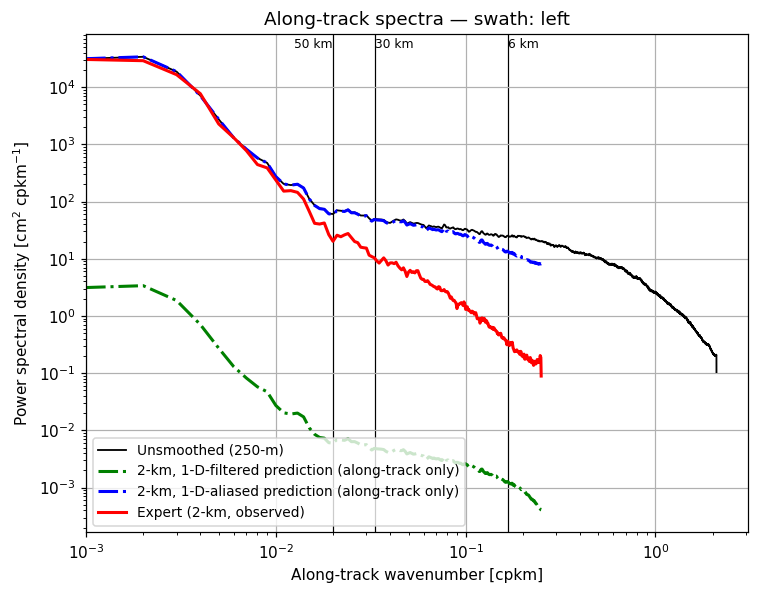

In [45]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mask_us = kx_us > 0
ax.loglog(kx_us[mask_us], psd_us[mask_us],
          ls="-", color="k", lw=1.2, label="Unsmoothed (250-m)")

mask_filt = kx_filtered > 0
ax.loglog(kx_filtered[mask_filt], psd_filtered[mask_filt],
          ls="-.", color="g", lw=2.0,
          label="2-km, 1-D-filtered prediction (along-track only)")

mask_alias = kx_alias > 0
ax.loglog(kx_alias[mask_alias], psd_aliased_pred[mask_alias],
          ls="-.", color="b", lw=2.0,
          label="2-km, 1-D-aliased prediction (along-track only)")

mask_ex = kx_ex > 0
ax.loglog(kx_ex[mask_ex], psd_ex[mask_ex],
          ls="-", color="r", lw=2.0, label="Expert (2-km, observed)")

ax.axvline(1 / 50.0, color="k", lw=0.8, zorder=0)
ax.axvline(1 / 30.0, color="k", lw=0.8, zorder=0)
ax.axvline(1 / 6.0, color="k", lw=0.8, zorder=0)
ymax = ax.get_ylim()[1]
ax.text(1 / 50.0, ymax/2, "50 km", ha="right", va="bottom", fontsize=8, color="k")
ax.text(1 / 30.0, ymax/2, "30 km", ha="left", va="bottom", fontsize=8, color="k")
ax.text(1 / 6.0, ymax/2, "6 km", ha="left", va="bottom", fontsize=8, color="k")

ax.set_xlabel("Along-track wavenumber [cpkm]")
ax.set_ylabel(f"Power spectral density [{'cm' if SSHA_UNITS_TO_CM != 1 else 'native'}$^2$ cpkm$^{{-1}}$]")
ax.set_title(f"Along-track spectra — swath: {SWATH}")
ax.legend(loc="lower left", fontsize=9)
ax.grid();ax.set_xlim(1/SEGMENT_LENGTH_KM,None)
fig.tight_layout()

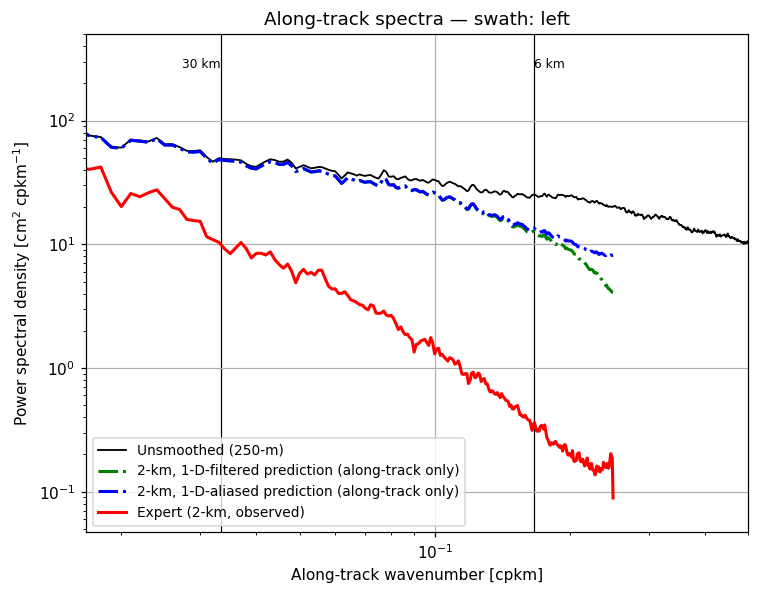

In [20]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mask_us = kx_us > 0
ax.loglog(kx_us[mask_us], psd_us[mask_us],
          ls="-", color="k", lw=1.2, label="Unsmoothed (250-m)")

mask_filt = kx_filtered > 0
ax.loglog(kx_filtered[mask_filt], psd_filtered[mask_filt],
          ls="-.", color="g", lw=2.0,
          label="2-km, 1-D-filtered prediction (along-track only)")

mask_alias = kx_alias > 0
ax.loglog(kx_alias[mask_alias], psd_aliased_pred[mask_alias],
          ls="-.", color="b", lw=2.0,
          label="2-km, 1-D-aliased prediction (along-track only)")
mask_ex = kx_ex > 0
ax.loglog(kx_ex[mask_ex], psd_ex[mask_ex],
          ls="-", color="r", lw=2.0, label="Expert (2-km, observed)")

ax.set_ylim(None, 5e2)
ax.axvline(1 / 30.0, color="k", lw=0.8, zorder=0)
ax.axvline(1 / 6.0, color="k", lw=0.8, zorder=0)
ymax = ax.get_ylim()[1]
ax.text(1 / 30.0, ymax/2, "30 km", ha="right", va="bottom", fontsize=8, color="k")
ax.text(1 / 6.0, ymax/2, "6 km", ha="left", va="bottom", fontsize=8, color="k")

ax.set_xlabel("Along-track wavenumber [cpkm]")
ax.set_ylabel(f"Power spectral density [{'cm' if SSHA_UNITS_TO_CM != 1 else 'native'}$^2$ cpkm$^{{-1}}$]")
ax.set_title(f"Along-track spectra — swath: {SWATH}")
ax.legend(loc="lower left", fontsize=9)
ax.grid();ax.set_xlim(1/60,0.5)
fig.tight_layout()
#fig.savefig("swot_spectra_comparison_1d.png", dpi=150)

## 8. (Optional) Local spectral slope

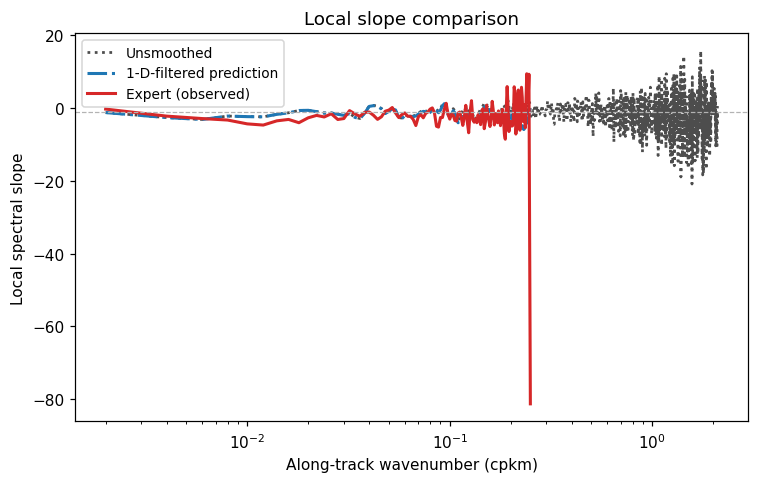

In [20]:
def local_slope(k, S):
    k = np.asarray(k); S = np.asarray(S)
    logk, logS = np.log10(k), np.log10(S)
    return np.gradient(logS, logk)


fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(kx_us[mask_us], local_slope(kx_us[mask_us], psd_us[mask_us]),
            ls=":", color="0.3", lw=1.8, label="Unsmoothed")
ax.semilogx(kx_filtered[mask_filt], local_slope(kx_filtered[mask_filt], psd_filtered[mask_filt]),
            ls="-.", color="tab:blue", lw=2.0, label="1-D-filtered prediction")
ax.semilogx(kx_ex[mask_ex], local_slope(kx_ex[mask_ex], psd_ex[mask_ex]),
            ls="-", color="tab:red", lw=2.0, label="Expert (observed)")
ax.axhline(-1, color="0.7", lw=0.8, ls="--")
ax.set_xlabel("Along-track wavenumber (cpkm)")
ax.set_ylabel("Local spectral slope")
ax.legend(fontsize=9)
ax.set_title("Local slope comparison")
fig.tight_layout()